2026-06-07 23:12:31.674212: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780873951.867622      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780873951.926273      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780873952.393092      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780873952.393141      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780873952.393144      23 computation_placer.cc:177] computation placer alr

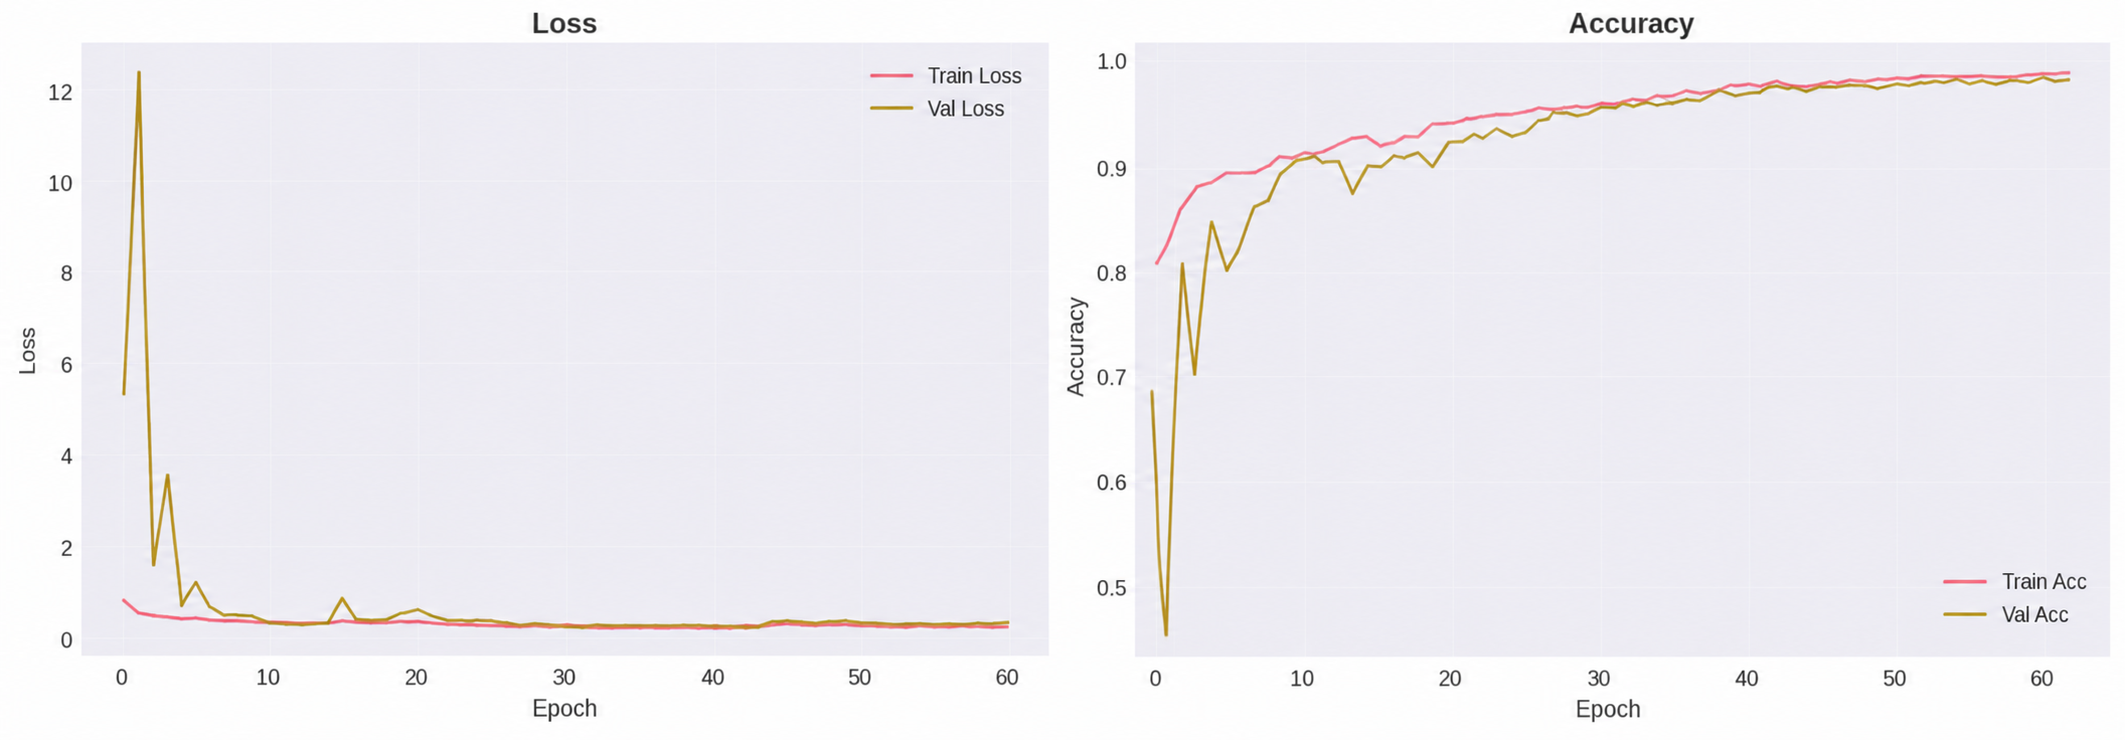


EVALUATION: V8_Phase4_CLAHE_PP_TTA

────────────────────────────────────────────────────────────────────────────────
STAGE 1: RAW PREDICTIONS
────────────────────────────────────────────────────────────────────────────────
  ✓ Saved: results/V8_Phase4_CLAHE_PP_TTA_raw_confusion_matrices.png


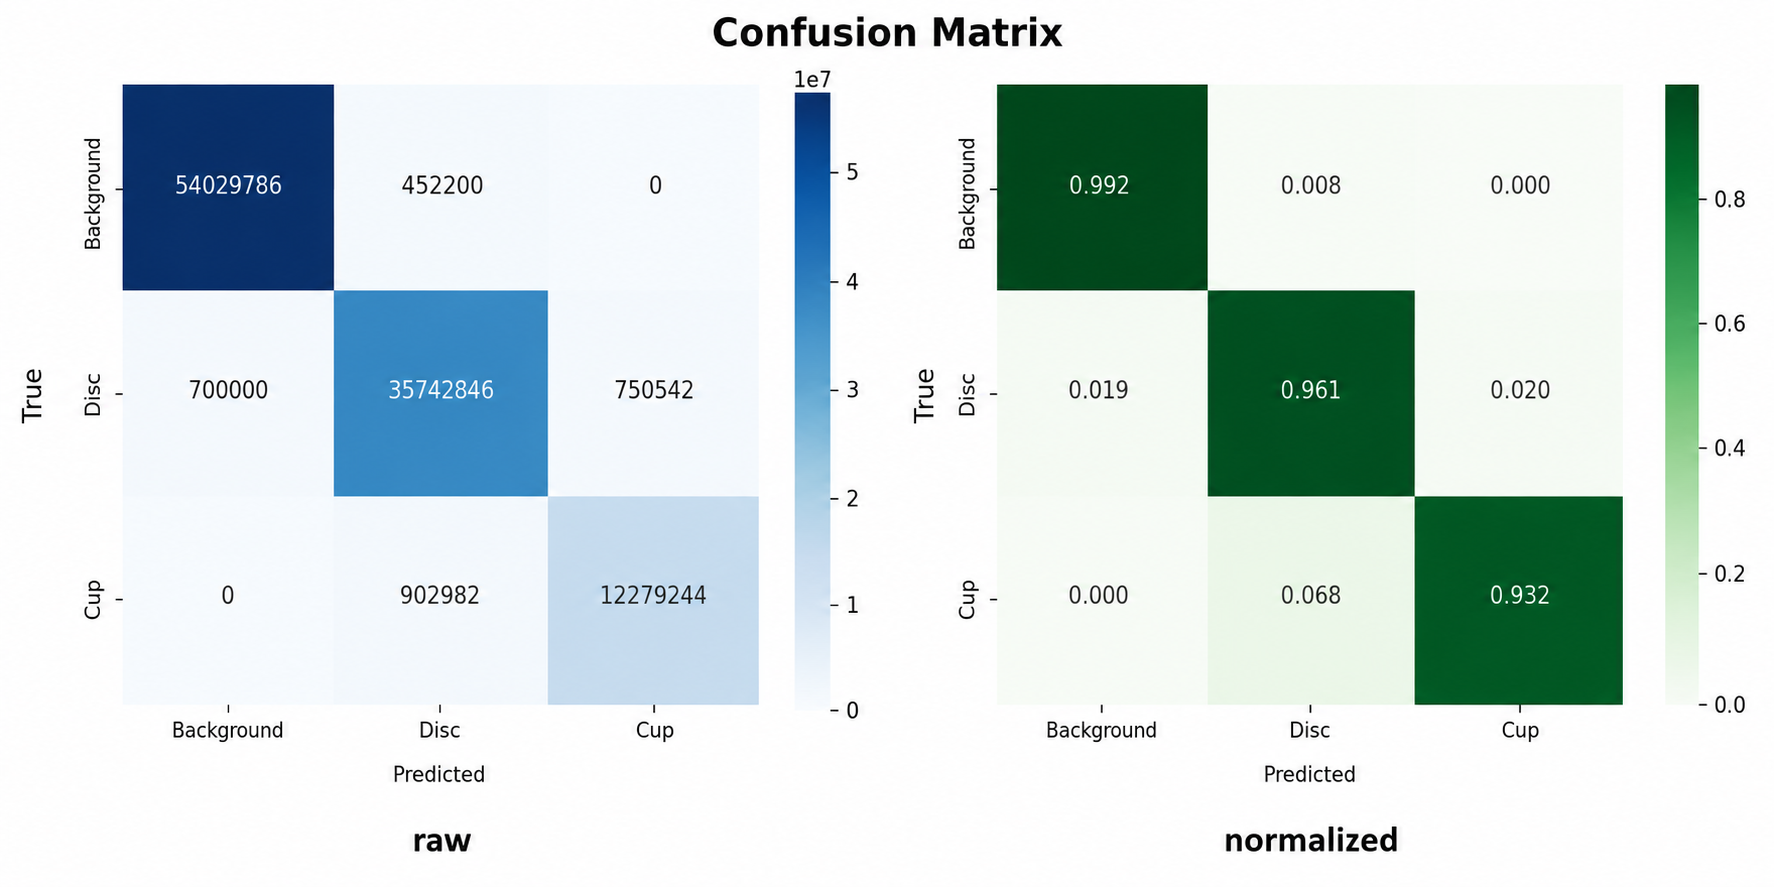

Raw metrics:
  Background: Precision=0.9925, Recall=0.9917, F1=0.9921
  Disc: Precision=0.9634, Recall=0.9610, F1=0.9622
  Cup: Precision=0.9281, Recall=0.9315, F1=0.9298

  Background: Dice=0.9921, IoU=0.9843
  Disc: Dice=0.9622, IoU=0.9272
  Cup: Dice=0.9298, IoU=0.8688

Overall (Macro Avg):
  Precision=0.9613, Recall=0.9614, F1=0.9613
  Dice=0.9613, IoU=0.9267

────────────────────────────────────────────────────────────────────────────────
STAGE 2: POST-PROCESSED
────────────────────────────────────────────────────────────────────────────────
Post-processed metrics:
  Background: Precision=0.9924, Recall=0.9916, F1=0.9920
  Disc: Precision=0.9634, Recall=0.9610, F1=0.9622
  Cup: Precision=0.9281, Recall=0.9315, F1=0.9298

  Background: Dice=0.9920 (-0.0001), IoU=0.9841
  Disc: Dice=0.9622 (+0.0000), IoU=0.9272
  Cup: Dice=0.9298 (+0.0000), IoU=0.8688

Overall (Macro Avg):
  Precision=0.9613, Recall=0.9613, F1=0.9613
  Dice=0.9613, IoU=0.9267

───────────────────────────────────────

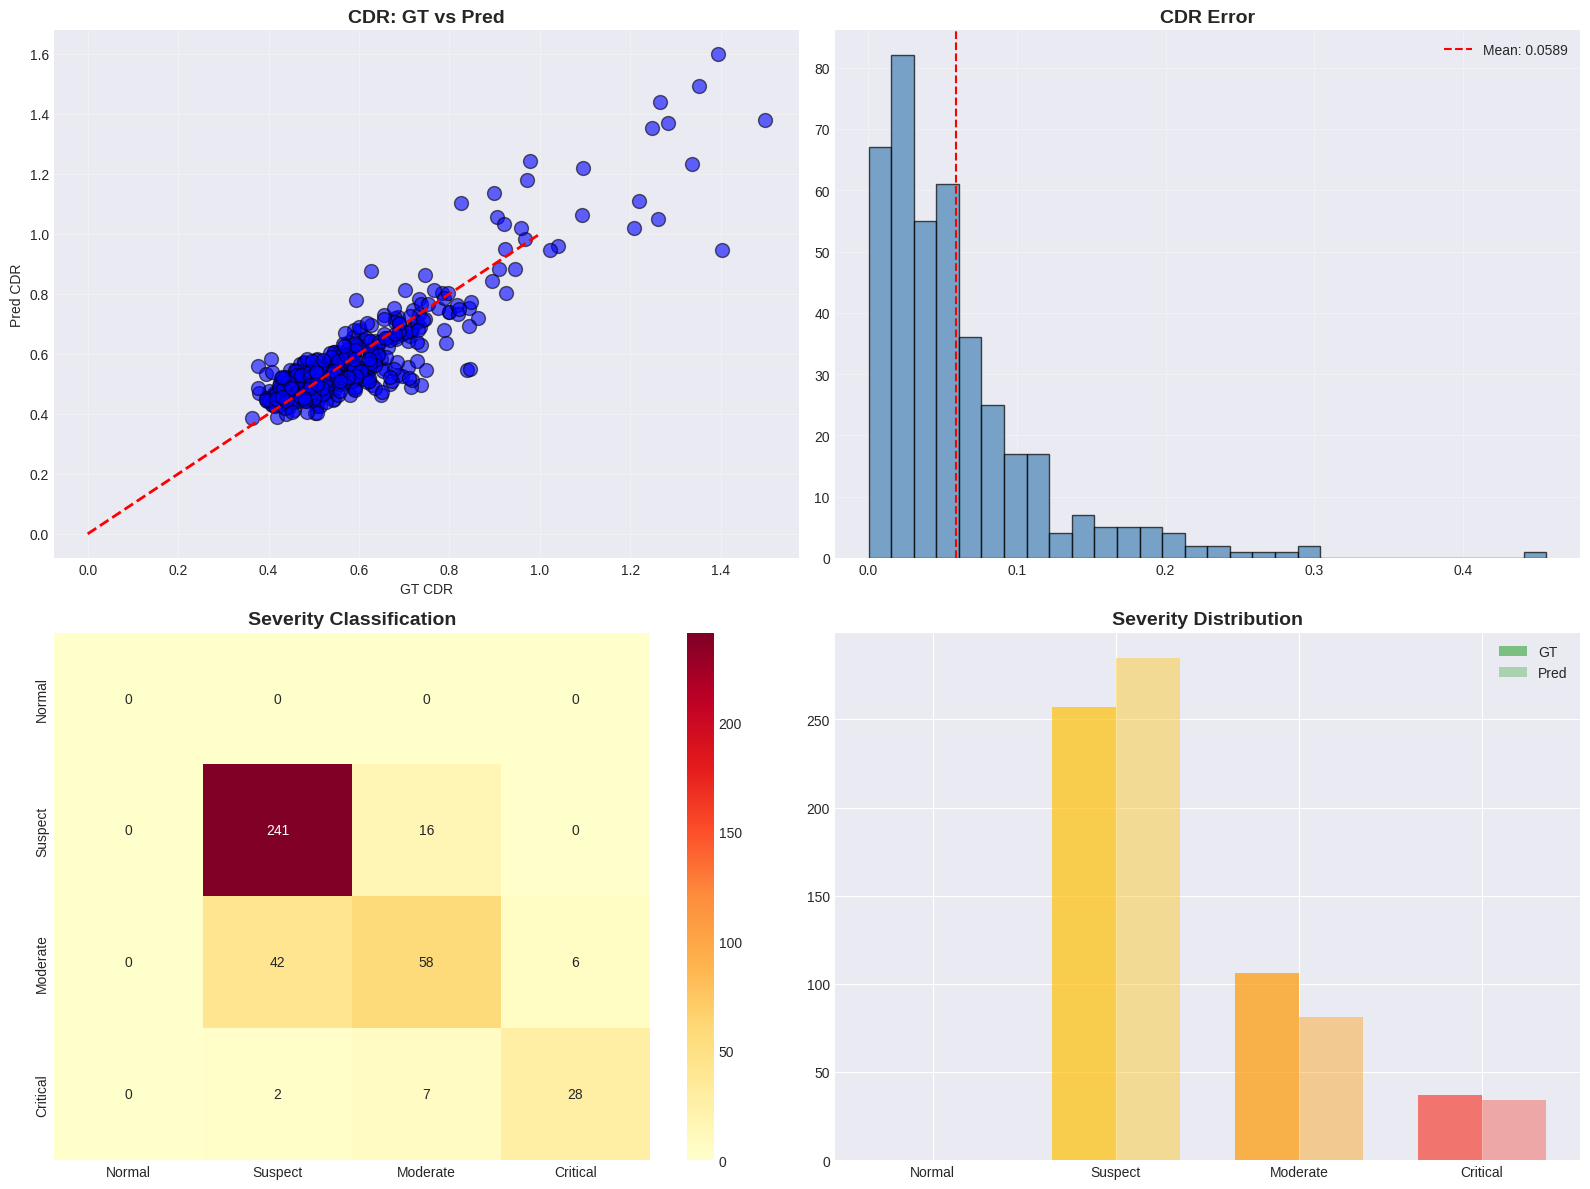


MC DROPOUT UNCERTAINTY

MC Dropout: 15 passes...
  5/15
  10/15
  15/15
  ✓ Done
  Background uncertainty: 0.0018
  Disc uncertainty: 0.0033
  Cup uncertainty: 0.0016

                                     ✓ COMPLETED — V8 + PHASE 4
  Model: V5 base + CLAHE + noise + PP + TTA + Phase 4
  Parameters: 47,631,627
  ROI: 1.2× padding, 512×512




In [3]:
"""
V8 + Phase 4: V5 BASE + CLAHE + MILD NOISE + PP + TTA + TRAINING REFINEMENTS
====================================================================
Everything from V8 (Phases 1-3) PLUS Phase 4 training refinements:

Phase 1 — Targeted Augmentation (V5 base + 2 safe additions):
  - V5's exact augmentation pipeline (proven Disc Dice=0.9349)
  - + CLAHE (fundus contrast normalization)
  - + Mild GaussNoise (var 5-25)
  - ROI padding: 1.2× (same as V5)
  - NO offline augmentation

Phase 2 — Post-Processing (during evaluation):
  - Largest connected component → Morphological closing → Hole filling
  - Median filter → Cup ⊂ disc constraint

Phase 3 — TTA: 4-pass flip ensemble

Phase 4 — Training Refinements (NEW vs Script 1):
  - Cosine Annealing Warm Restarts: T_0=15, T_mult=2, η_min=1e-7
  - Label smoothing: 0.05
  - Disc focal weight: α=[0.25, 1.3, 1.0] (conservative boost)
  - 100 epochs, patience=20

Architecture UNCHANGED:
  - MobileNetV2 encoder + Deeper Decoder
  - MSCA + LBFR + PPM triple attention (12 modules)
  - MC Dropout (15 forward passes)
"""

import os
import gc
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from PIL import Image
import cv2

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# GPU CONFIGURATION
# ============================================================================

def configure_gpu():
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
            print(f"✓ GPU configured: {len(physical_devices)} device(s) available")
            return True
        except RuntimeError as e:
            print(f"GPU configuration error: {e}")
            return False
    else:
        print("⚠ No GPU detected, running on CPU")
        return False

# ============================================================================
# COSINE ANNEALING WARM RESTARTS (Phase 4)
# ============================================================================

class CosineAnnealingWarmRestarts(Callback):
    """
    Cosine Annealing with Warm Restarts (Loshchilov & Hutter, 2017).
    LR cycles: T_0=15 → 30 → 60 epochs (T_mult=2)
    """
    def __init__(self, T_0=15, T_mult=2, eta_max=2e-4, eta_min=1e-7, verbose=1):
        super().__init__()
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_max = eta_max
        self.eta_min = eta_min
        self.verbose = verbose
        self.T_cur = 0
        self.T_i = T_0
        self.cycle = 0

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.eta_max - self.eta_min) * \
             (1 + math.cos(math.pi * self.T_cur / self.T_i)) / 2
        if hasattr(self.model.optimizer.learning_rate, 'assign'):
            self.model.optimizer.learning_rate.assign(lr)
        else:
            self.model.optimizer.learning_rate = lr
        if self.verbose and (epoch % 10 == 0 or self.T_cur == 0):
            print(f"  Cosine LR: epoch={epoch}, cycle={self.cycle}, T_cur={self.T_cur}/{self.T_i}, lr={lr:.2e}")
        self.T_cur += 1
        if self.T_cur >= self.T_i:
            self.T_cur = 0
            self.T_i = int(self.T_i * self.T_mult)
            self.cycle += 1
            if self.verbose:
                print(f"  ↻ Warm restart #{self.cycle}: next cycle length = {self.T_i} epochs")

# ============================================================================
# DATA LOADING
# ============================================================================

def load_images_masks(images_folder, masks_folder, img_size=(512,512)):
    images, masks = [], []
    image_files = sorted(os.listdir(images_folder))
    mask_files = sorted(os.listdir(masks_folder))
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    for img_file in image_files:
        img_path = os.path.join(images_folder, img_file)
        img = np.array(Image.open(img_path).resize(img_size)) / 255.0
        images.append(img)
        img_name = os.path.splitext(img_file)[0]
        if img_name in mask_dict:
            mask_path = os.path.join(masks_folder, mask_dict[img_name])
            mask = np.array(Image.open(mask_path).resize(img_size, Image.NEAREST))
            masks.append(mask)
        else:
            print(f"Warning: No mask found for {img_file}")
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

def load_all_data(root_dir):
    all_images, all_masks = [], []
    for split in ["train", "val", "test"]:
        print(f"Loading {split} data...")
        imgs, msks = load_images_masks(
            os.path.join(root_dir, split, "Images"),
            os.path.join(root_dir, split, "Masks"))
        all_images.append(imgs)
        all_masks.append(msks)
        print(f"  {split}: {imgs.shape[0]} samples")
    return np.concatenate(all_images, axis=0), np.concatenate(all_masks, axis=0)

def create_new_split(all_images, all_masks):
    X_temp, X_test, y_temp, y_test = train_test_split(all_images, all_masks, test_size=400, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=200, random_state=42)
    print(f"Split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def load_all_data_with_highres_roi(root_dir, roi_size=(512, 512), padding_factor=1.2):
    """Load at original resolution, extract ROI, resize to roi_size. Padding=1.2× (same as V5)."""
    all_roi_images, all_roi_masks, all_full_masks_512 = [], [], []
    for split in ["train", "val", "test"]:
        images_folder = os.path.join(root_dir, split, "Images")
        masks_folder = os.path.join(root_dir, split, "Masks")
        image_files = sorted(os.listdir(images_folder))
        mask_files = sorted(os.listdir(masks_folder))
        mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
        count = 0
        for img_file in image_files:
            img_name = os.path.splitext(img_file)[0]
            if img_name not in mask_dict:
                continue
            img_highres = np.array(Image.open(os.path.join(images_folder, img_file))) / 255.0
            mask_highres = np.array(Image.open(os.path.join(masks_folder, mask_dict[img_name])))
            roi_img, roi_msk, _ = extract_roi(img_highres, mask_highres, padding_factor, roi_size)
            all_roi_images.append(roi_img)
            all_roi_masks.append(roi_msk)
            full_msk_512 = np.array(Image.fromarray(mask_highres).resize((512, 512), Image.NEAREST))
            all_full_masks_512.append(full_msk_512)
            del img_highres, mask_highres
            count += 1
        print(f"  {split}: {count} samples (original resolution -> ROI extracted)")
    return (np.array(all_roi_images, dtype=np.float32),
            np.array(all_roi_masks, dtype=np.uint8),
            np.array(all_full_masks_512, dtype=np.uint8))

# ============================================================================
# ROI EXTRACTION (identical to V5)
# ============================================================================

def find_disc_region(mask, disc_class=1, cup_class=2):
    roi_mask = ((mask == disc_class) | (mask == cup_class)).astype(np.uint8)
    if roi_mask.sum() == 0:
        return None
    coords = np.where(roi_mask > 0)
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()
    center_y = (y_min + y_max) // 2
    center_x = (x_min + x_max) // 2
    radius = max(y_max - y_min, x_max - x_min) // 2
    return center_y, center_x, radius

def extract_roi(image, mask, padding_factor=1.2, roi_size=(512, 512)):
    """Extract ROI around optic disc. Padding=1.2× (same as V5)."""
    result = find_disc_region(mask)
    if result is None:
        h, w = image.shape[:2]
        return image.copy(), mask.copy(), (0, 0, h, w)
    center_y, center_x, radius = result
    h, w = image.shape[:2]
    roi_half = max(int(radius * padding_factor), 60)
    y1 = max(0, center_y - roi_half)
    y2 = min(h, center_y + roi_half)
    x1 = max(0, center_x - roi_half)
    x2 = min(w, center_x + roi_half)
    crop_h, crop_w = y2 - y1, x2 - x1
    if crop_h > crop_w:
        diff = crop_h - crop_w
        x1 = max(0, x1 - diff // 2)
        x2 = min(w, x1 + crop_h)
        x1 = max(0, x2 - crop_h)
    elif crop_w > crop_h:
        diff = crop_w - crop_h
        y1 = max(0, y1 - diff // 2)
        y2 = min(h, y1 + crop_w)
        y1 = max(0, y2 - crop_w)
    roi_image = image[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]
    roi_image_pil = Image.fromarray((roi_image * 255).astype(np.uint8))
    roi_image_resized = np.array(roi_image_pil.resize(roi_size, Image.BILINEAR)) / 255.0
    roi_mask_pil = Image.fromarray(roi_mask)
    roi_mask_resized = np.array(roi_mask_pil.resize(roi_size, Image.NEAREST))
    return roi_image_resized.astype(np.float32), roi_mask_resized.astype(np.uint8), (y1, x1, y2, x2)

def extract_roi_batch(images, masks, padding_factor=1.2, roi_size=(512, 512)):
    roi_images, roi_masks, roi_coords_list = [], [], []
    for i in range(len(images)):
        roi_img, roi_msk, coords = extract_roi(images[i], masks[i], padding_factor, roi_size)
        roi_images.append(roi_img)
        roi_masks.append(roi_msk)
        roi_coords_list.append(coords)
    return (np.array(roi_images, dtype=np.float32),
            np.array(roi_masks, dtype=np.uint8), roi_coords_list)

def map_roi_prediction_to_full(pred_mask_roi, roi_coords, full_size=(512, 512)):
    y1, x1, y2, x2 = roi_coords
    pred_pil = Image.fromarray(pred_mask_roi.astype(np.uint8))
    pred_resized = np.array(pred_pil.resize((x2-x1, y2-y1), Image.NEAREST))
    full_mask = np.zeros(full_size, dtype=np.uint8)
    full_mask[y1:y2, x1:x2] = pred_resized
    return full_mask

# ============================================================================
# DATA AUGMENTATION (V5 base + CLAHE + mild GaussNoise)
# ============================================================================

def setup_augmentations():
    """
    V5's EXACT augmentation pipeline + 2 targeted safe additions:
    - CLAHE: fundus contrast normalization (intensity only)
    - GaussNoise (mild): small variance, doesn't deform boundaries
    """
    return A.Compose([
        # === V5 base (EXACT SAME as roi-best) ===
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=20,
                           border_mode=0, p=0.6),
        A.ElasticTransform(alpha=30, sigma=5, p=0.2),
        A.RandomBrightnessContrast(brightness_limit=0.20, contrast_limit=0.20, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
        # === 2 safe additions ===
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    ])

def smooth_labels(y_cat, smoothing=0.05):
    """Label smoothing: [0, 1, 0] → [0.017, 0.967, 0.017] with smoothing=0.05"""
    num_classes = y_cat.shape[-1]
    return y_cat * (1.0 - smoothing) + smoothing / num_classes

def data_generator(images, masks, batch_size, augment=None, label_smoothing=0.0):
    """Data generator with optional label smoothing (Phase 4)."""
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                if augment:
                    img_uint8 = (img * 255).astype(np.uint8)
                    aug = augment(image=img_uint8, mask=mask)
                    img_aug = aug['image'].astype(np.float32) / 255.0
                    mask_aug = aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                mask_cat = to_categorical(mask_aug, num_classes=3)
                if label_smoothing > 0:
                    mask_cat = smooth_labels(mask_cat, smoothing=label_smoothing)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            yield np.stack(batch_x).astype(np.float32), np.stack(batch_y).astype(np.float32)

# ============================================================================
# POST-PROCESSING PIPELINE (Phase 2)
# ============================================================================

def postprocess_prediction(pred_mask):
    """MBG-Net-style post-processing pipeline."""
    cleaned = pred_mask.copy()
    for class_id in [1, 2]:
        if class_id == 1:
            binary = ((cleaned == 1) | (cleaned == 2)).astype(np.uint8)
        else:
            binary = (cleaned == class_id).astype(np.uint8)
        if binary.sum() == 0:
            continue
        # 1. Largest connected component
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        if num_labels > 2:
            largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            binary = (labels == largest).astype(np.uint8)
        # 2. Morphological closing
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        # 3. Hole filling
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cv2.drawContours(binary, contours, -1, 1, cv2.FILLED)
        # 4. Median filter
        binary = cv2.medianBlur(binary, 5)

        if class_id == 1:
            cup_preserved = (cleaned == 2).astype(np.uint8)
            cleaned[cleaned == 1] = 0
            cleaned[cleaned == 2] = 0
            cleaned[binary == 1] = 1
            cup_in_disc = cup_preserved & binary
            cleaned[cup_in_disc == 1] = 2
        else:
            disc_region = ((cleaned == 1) | (cleaned == 2)).astype(np.uint8)
            binary = binary & disc_region
            cleaned[cleaned == 2] = 0
            cleaned[binary == 1] = 2
    # 5. Cup ⊂ disc
    cup_mask = (cleaned == 2).astype(np.uint8)
    disc_full = ((cleaned == 1) | (cleaned == 2)).astype(np.uint8)
    cup_outside = cup_mask & (~disc_full.astype(bool)).astype(np.uint8)
    if cup_outside.sum() > 0:
        cleaned[cup_outside == 1] = 1
    return cleaned

def postprocess_batch(pred_masks):
    return np.array([postprocess_prediction(m) for m in pred_masks], dtype=np.uint8)

# ============================================================================
# TEST-TIME AUGMENTATION (Phase 3)
# ============================================================================

def predict_with_tta(model, images, batch_size=4):
    """4-pass TTA: average softmax over geometric augmentations."""
    print(f"\nRunning TTA with 4 geometric passes...")
    print(f"  Pass 1/4: Original")
    pred_orig = model.predict(images, verbose=0, batch_size=batch_size)
    print(f"  Pass 2/4: Horizontal flip")
    images_hflip = np.flip(images, axis=2).copy()
    pred_hflip = np.flip(model.predict(images_hflip, verbose=0, batch_size=batch_size), axis=2)
    del images_hflip
    print(f"  Pass 3/4: Vertical flip")
    images_vflip = np.flip(images, axis=1).copy()
    pred_vflip = np.flip(model.predict(images_vflip, verbose=0, batch_size=batch_size), axis=1)
    del images_vflip
    print(f"  Pass 4/4: Both flips")
    images_hvflip = np.flip(np.flip(images, axis=2), axis=1).copy()
    pred_hvflip = np.flip(np.flip(
        model.predict(images_hvflip, verbose=0, batch_size=batch_size), axis=2), axis=1)
    del images_hvflip
    avg_pred = (pred_orig + pred_hflip + pred_vflip + pred_hvflip) / 4.0
    del pred_orig, pred_hflip, pred_vflip, pred_hvflip
    gc.collect()
    print(f"  ✓ TTA completed")
    return np.argmax(avg_pred, axis=-1), avg_pred

# ============================================================================
# MSCA MODULE
# ============================================================================

def msca_block(x, channels, dilation_rates=[1, 2, 3, 5], block_name='msca'):
    multi_scale_features = []
    filters_per_branch = channels // len(dilation_rates)
    for i, rate in enumerate(dilation_rates):
        branch = layers.Conv2D(filters_per_branch, (3, 3), padding='same',
            dilation_rate=rate, use_bias=False, name=f'{block_name}_dil{rate}_conv')(x)
        branch = layers.BatchNormalization(name=f'{block_name}_dil{rate}_bn')(branch)
        branch = layers.Activation('relu', name=f'{block_name}_dil{rate}_relu')(branch)
        multi_scale_features.append(branch)
    concat = layers.Concatenate(name=f'{block_name}_concat')(multi_scale_features)
    fused = layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_fusion')(concat)
    fused = layers.BatchNormalization(name=f'{block_name}_fusion_bn')(fused)
    fused = layers.Activation('relu', name=f'{block_name}_fusion_relu')(fused)
    return layers.Add(name=f'{block_name}_residual')([x, fused])

# ============================================================================
# LBFR MODULE
# ============================================================================

def lbfr_block(x, channels, reduction=16, block_name='lbfr'):
    avg_pool = layers.GlobalAveragePooling2D(name=f'{block_name}_avg_pool')(x)
    avg_pool = layers.Reshape((1, 1, channels), name=f'{block_name}_avg_reshape')(avg_pool)
    max_pool = layers.GlobalMaxPooling2D(name=f'{block_name}_max_pool')(x)
    max_pool = layers.Reshape((1, 1, channels), name=f'{block_name}_max_reshape')(max_pool)
    fc1 = layers.Conv2D(channels // reduction, (1, 1), use_bias=False, name=f'{block_name}_fc1')
    fc2 = layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_fc2')
    avg_out = fc2(layers.Activation('relu', name=f'{block_name}_fc1_relu_avg')(fc1(avg_pool)))
    max_out = fc2(layers.Activation('relu', name=f'{block_name}_fc1_relu_max')(fc1(max_pool)))
    channel_att = layers.Activation('sigmoid', name=f'{block_name}_channel_sigmoid')(
        layers.Add(name=f'{block_name}_channel_add')([avg_out, max_out]))
    x_channel = layers.Multiply(name=f'{block_name}_channel_multiply')([x, channel_att])
    avg_spatial = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True), name=f'{block_name}_spatial_avg')(x_channel)
    max_spatial = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True), name=f'{block_name}_spatial_max')(x_channel)
    spatial_concat = layers.Concatenate(name=f'{block_name}_spatial_concat')([avg_spatial, max_spatial])
    spatial_att = layers.Activation('sigmoid', name=f'{block_name}_spatial_sigmoid')(
        layers.Conv2D(1, (7, 7), padding='same', use_bias=False, name=f'{block_name}_spatial_conv')(spatial_concat))
    x_spatial = layers.Multiply(name=f'{block_name}_spatial_multiply')([x_channel, spatial_att])
    recalibrated = layers.BatchNormalization(name=f'{block_name}_recalibrate_bn')(
        layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_recalibrate')(x_spatial))
    return layers.Add(name=f'{block_name}_residual')([x, recalibrated])

# ============================================================================
# PPM MODULE
# ============================================================================

def ppm_block(x, channels, pool_scales=[1, 2, 3, 6], block_name='ppm'):
    h, w = x.shape[1], x.shape[2]
    ppm_features = [x]
    filters_per_scale = channels // len(pool_scales)
    for i, scale in enumerate(pool_scales):
        pool_h, pool_w = max(h // scale, 1), max(w // scale, 1)
        pooled = layers.AveragePooling2D(pool_size=(h//pool_h, w//pool_w),
            strides=(h//pool_h, w//pool_w), name=f'{block_name}pool{scale}x{scale}')(x)
        conv = layers.Activation('relu', name=f'{block_name}relu{scale}x{scale}')(
            layers.BatchNormalization(name=f'{block_name}bn{scale}x{scale}')(
                layers.Conv2D(filters_per_scale, (1, 1), use_bias=False,
                    name=f'{block_name}conv{scale}x{scale}')(pooled)))
        upsampled = layers.Resizing(h, w, interpolation='bilinear',
            name=f'{block_name}upsample{scale}x{scale}')(conv)
        ppm_features.append(upsampled)
    concat = layers.Concatenate(name=f'{block_name}_concat')(ppm_features)
    fused = layers.Activation('relu', name=f'{block_name}_fusion_relu')(
        layers.BatchNormalization(name=f'{block_name}_fusion_bn')(
            layers.Conv2D(channels, (3, 3), padding='same', use_bias=False,
                name=f'{block_name}_fusion')(concat)))
    return fused

# ============================================================================
# LOSS FUNCTIONS (Phase 4: disc α boosted to 1.3)
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    """Phase 4: alpha=[0.25, 1.3, 1.0] — conservative disc weight boost"""
    if alpha is None:
        alpha = [0.25, 1.3, 1.0]  # ← Phase 4: disc α 1.0 → 1.3
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        bce = -(y_true_c * K.log(y_pred_c) + (1 - y_true_c) * K.log(1 - y_pred_c))
        pt = y_true_c * y_pred_c + (1 - y_true_c) * (1 - y_pred_c)
        focal_weight = K.pow(1 - pt, gamma)
        focal_loss_value += alpha[c] * K.mean(focal_weight * bce)
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    eiou_loss_value = 0.0
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        binary_true = K.cast(y_true_c > 0.5, 'float32')
        binary_pred = K.cast(y_pred_c > 0.5, 'float32')
        _h = tf.cast(tf.shape(y_true_c)[1], 'float32')
        _w = tf.cast(tf.shape(y_true_c)[2], 'float32')
        row_coords = tf.reshape(tf.range(tf.shape(y_true_c)[1], dtype=tf.float32) / _h, [1, -1, 1])
        col_coords = tf.reshape(tf.range(tf.shape(y_true_c)[2], dtype=tf.float32) / _w, [1, 1, -1])
        rp_t = K.max(binary_true, axis=2, keepdims=True)
        rp_p = K.max(binary_pred, axis=2, keepdims=True)
        cp_t = K.max(binary_true, axis=1, keepdims=True)
        cp_p = K.max(binary_pred, axis=1, keepdims=True)
        y_min_t = K.min(row_coords + (1.0 - rp_t), axis=[1, 2])
        y_max_t = K.max(row_coords * rp_t, axis=[1, 2])
        x_min_t = K.min(col_coords + (1.0 - cp_t), axis=[1, 2])
        x_max_t = K.max(col_coords * cp_t, axis=[1, 2])
        y_min_p = K.min(row_coords + (1.0 - rp_p), axis=[1, 2])
        y_max_p = K.max(row_coords * rp_p, axis=[1, 2])
        x_min_p = K.min(col_coords + (1.0 - cp_p), axis=[1, 2])
        x_max_p = K.max(col_coords * cp_p, axis=[1, 2])
        y_true_bbox = K.stack([y_min_t, x_min_t, y_max_t, x_max_t], axis=-1)
        y_pred_bbox = K.stack([y_min_p, x_min_p, y_max_p, x_max_p], axis=-1)
        center_true = K.stack([(y_true_bbox[:,0]+y_true_bbox[:,2])/2, (y_true_bbox[:,1]+y_true_bbox[:,3])/2], axis=-1)
        center_pred = K.stack([(y_pred_bbox[:,0]+y_pred_bbox[:,2])/2, (y_pred_bbox[:,1]+y_pred_bbox[:,3])/2], axis=-1)
        center_distance = K.sum(K.square(center_true - center_pred), axis=-1)
        diag_length = K.maximum(K.square(y_true_bbox[:,2]-y_true_bbox[:,0]) + K.square(y_true_bbox[:,3]-y_true_bbox[:,1]), 1e-7)
        eiou = iou - (center_distance / diag_length)
        eiou_loss_value += K.mean(1.0 - eiou)
    return eiou_loss_value / 3.0

def focal_eiou_combined_loss(y_true, y_pred, focal_weight=1.0, eiou_weight=1.0, gamma=2.0, alpha=None):
    fl = focal_loss(y_true, y_pred, gamma=gamma, alpha=alpha)
    eiou = enhanced_iou_loss(y_true, y_pred)
    return focal_weight * fl + eiou_weight * eiou

# ============================================================================
# MODEL ARCHITECTURE (identical to V5)
# ============================================================================

def enhanced_decoder_block_with_triple_attention(x, skip_connection, filters, block_name, dropout_rate=0.3):
    x = layers.UpSampling2D((2, 2), name=f'{block_name}_upsample')(x)
    if skip_connection.shape[-1] != x.shape[-1]:
        skip_connection = layers.Conv2D(x.shape[-1], (1, 1), padding='same', name=f'{block_name}_skip_adjust')(skip_connection)
    x = layers.Concatenate(name=f'{block_name}_concat')([x, skip_connection])
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout')(x)
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv3')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn3')(x)
    residual = x
    x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same', name=f'{block_name}_conv4')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn4')(x)
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    x = layers.Conv2D(filters, (1, 1), activation='relu', padding='same', name=f'{block_name}_conv_final')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn_final')(x)
    x = msca_block(x, filters, dilation_rates=[1, 2, 3, 5], block_name=f'{block_name}_msca')
    x = lbfr_block(x, filters, reduction=16, block_name=f'{block_name}_lbfr')
    x = ppm_block(x, filters, pool_scales=[1, 2, 3, 6], block_name=f'{block_name}_ppm')
    return x

def build_unet_with_triple_attention(input_shape=(512, 512, 3), num_classes=3, dropout_rate=0.3):
    inputs = layers.Input(input_shape, dtype='float32')
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    skip_1 = backbone.get_layer('block_1_expand_relu').output
    skip_2 = backbone.get_layer('block_3_expand_relu').output
    skip_3 = backbone.get_layer('block_6_expand_relu').output
    skip_4 = backbone.get_layer('block_13_expand_relu').output
    bridge = backbone.output
    bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
    bridge = layers.BatchNormalization()(bridge)
    bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    x = enhanced_decoder_block_with_triple_attention(bridge, skip_4, 512, 'decoder_1', dropout_rate)
    x = enhanced_decoder_block_with_triple_attention(x, skip_3, 256, 'decoder_2', dropout_rate)
    x = enhanced_decoder_block_with_triple_attention(x, skip_2, 128, 'decoder_3', dropout_rate * 0.7)
    x = enhanced_decoder_block_with_triple_attention(x, skip_1, 64, 'decoder_4', dropout_rate * 0.5)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    model = models.Model(inputs, outputs)
    print(f"\nModel: {model.count_params():,} params | MSCA+LBFR+PPM triple attention (12 blocks)")
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f, y_pred_f = K.flatten(y_true), K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f, y_pred_f = K.flatten(y_true), K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    if verbose: print(f"\nMC Dropout: {num_samples} passes...")
    sum_preds, sum_sq_preds = None, None
    num_batches = int(np.ceil(len(X) / batch_size))
    for i in range(num_samples):
        if verbose and (i+1)%5==0: print(f"  {i+1}/{num_samples}")
        batch_preds = []
        for bi in range(num_batches):
            s, e = bi*batch_size, min((bi+1)*batch_size, len(X))
            batch_preds.append(model(X[s:e], training=True).numpy())
        cur = np.concatenate(batch_preds, axis=0)
        if sum_preds is None:
            sum_preds, sum_sq_preds = cur.astype(np.float32), np.square(cur).astype(np.float32)
        else:
            sum_preds += cur; sum_sq_preds += np.square(cur)
        del cur, batch_preds
        if (i+1)%5==0: gc.collect()
    mean_pred = sum_preds / num_samples
    std_pred = np.sqrt(np.maximum(sum_sq_preds/num_samples - np.square(mean_pred), 0))
    del sum_preds, sum_sq_preds; gc.collect()
    if verbose: print("  ✓ Done")
    return mean_pred, std_pred

# ============================================================================
# GLAUCOMA SCORING
# ============================================================================

def calculate_cdr(mask, disc_class=1, cup_class=2, method='vertical'):
    disc_mask = (mask == disc_class).astype(np.uint8)
    cup_mask = (mask == cup_class).astype(np.uint8)
    disc_area, cup_area = disc_mask.sum(), cup_mask.sum()
    if disc_area == 0 or cup_area == 0:
        return {'vCDR': 0.0, 'hCDR': 0.0, 'avgCDR': 0.0, 'area_CDR': 0.0, 'valid': False,
                'method': method, 'disc_area': 0, 'cup_area': 0}
    dc, cc = np.where(disc_mask > 0), np.where(cup_mask > 0)
    dv = dc[0].max()-dc[0].min()+1; cv = cc[0].max()-cc[0].min()+1
    dh = dc[1].max()-dc[1].min()+1; ch = cc[1].max()-cc[1].min()+1
    vCDR = cv/dv if dv>0 else 0; hCDR = ch/dh if dh>0 else 0
    area_CDR = np.sqrt(cup_area/disc_area)
    avgCDR = vCDR if method=='vertical' else area_CDR if method=='area_sqrt' else (vCDR+hCDR)/2
    return {'vCDR': float(vCDR), 'hCDR': float(hCDR), 'avgCDR': float(avgCDR),
            'area_CDR': float(area_CDR), 'valid': True, 'method': method,
            'disc_area': int(disc_area), 'cup_area': int(cup_area),
            'disc_v_diameter': int(dv), 'cup_v_diameter': int(cv)}

def classify_glaucoma_severity(cdr):
    if cdr < 0.3: return 0, 'Normal', '#4CAF50'
    elif cdr < 0.6: return 1, 'Suspect', '#FFC107'
    elif cdr < 0.8: return 2, 'Moderate', '#FF9800'
    else: return 3, 'Critical', '#F44336'

def analyze_glaucoma_progression(masks, predictions, cdr_method='area_sqrt'):
    results = []
    for i, (gt, pred) in enumerate(zip(masks, predictions)):
        g, p = calculate_cdr(gt, method=cdr_method), calculate_cdr(pred, method=cdr_method)
        gl = classify_glaucoma_severity(g['avgCDR']) if g['valid'] else (-1, 'Invalid', '#9E9E9E')
        pl = classify_glaucoma_severity(p['avgCDR']) if p['valid'] else (-1, 'Invalid', '#9E9E9E')
        err = abs(g['avgCDR']-p['avgCDR']) if g['valid'] and p['valid'] else np.nan
        sm = (gl[1]==pl[1]); mr = (gl[1]=='Critical') or (not sm)
        results.append({'Sample': i+1, 'GT_vCDR': g['vCDR'], 'GT_hCDR': g['hCDR'],
            'GT_avgCDR': g['avgCDR'], 'GT_area_CDR': g['area_CDR'], 'GT_Severity': gl[1],
            'Pred_vCDR': p['vCDR'], 'Pred_hCDR': p['hCDR'], 'Pred_avgCDR': p['avgCDR'],
            'Pred_area_CDR': p['area_CDR'], 'Pred_Severity': pl[1],
            'CDR_Error': err, 'Severity_Match': sm, 'Manual_Review_Needed': mr})
    return pd.DataFrame(results)

def calculate_progression_accuracy(df):
    total = len(df); correct = df['Severity_Match'].sum()
    r = {'overall': {'total': total, 'correct': correct, 'accuracy': correct/total*100}, 'per_class': {}}
    for s in ['Normal','Suspect','Moderate','Critical']:
        gc_ = len(df[df['GT_Severity']==s]); pc = len(df[df['Pred_Severity']==s])
        cc = len(df[(df['GT_Severity']==s)&(df['Pred_Severity']==s)])
        r['per_class'][s] = {'gt_count':gc_, 'pred_count':pc, 'correct':cc, 'accuracy': cc/gc_*100 if gc_>0 else 0}
    mr = df['Manual_Review_Needed'].sum()
    r['manual_review'] = {'count': mr, 'percentage': mr/total*100}
    return r

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_training_history(history, model_name, save_dir='results'):
    os.makedirs(save_dir, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_history.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_history.png"); plt.show(); plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    os.makedirs(save_dir, exist_ok=True)
    yt = np.argmax(y_true, axis=-1).flatten(); yp = np.argmax(y_pred, axis=-1).flatten()
    cm = confusion_matrix(yt, yp); cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6)); cn = ['Background', 'Disc', 'Cup']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cn, yticklabels=cn, ax=axes[0])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    sns.heatmap(cmn, annot=True, fmt='.3f', cmap='Greens', xticklabels=cn, yticklabels=cn, ax=axes[1])
    axes[1].set_title(f'{model_name}\nNormalized', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_confusion_matrices.png"); plt.show(); plt.close()
    return cm, cmn

def plot_cdr_distribution(df, save_dir='results'):
    os.makedirs(save_dir, exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0,0].scatter(df['GT_avgCDR'], df['Pred_avgCDR'], alpha=0.6, s=100, c='blue', edgecolors='black')
    axes[0,0].plot([0,1],[0,1],'r--',linewidth=2); axes[0,0].set_title('CDR: GT vs Pred', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('GT CDR'); axes[0,0].set_ylabel('Pred CDR'); axes[0,0].grid(True, alpha=0.3)
    ve = df['CDR_Error'].dropna()
    axes[0,1].hist(ve, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0,1].axvline(ve.mean(), color='red', linestyle='--', label=f'Mean: {ve.mean():.4f}')
    axes[0,1].set_title('CDR Error', fontsize=14, fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
    so = ['Normal','Suspect','Moderate','Critical']
    gs = pd.Categorical(df['GT_Severity'], categories=so, ordered=True)
    ps = pd.Categorical(df['Pred_Severity'], categories=so, ordered=True)
    cm = confusion_matrix(gs, ps, labels=so)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=so, yticklabels=so, ax=axes[1,0])
    axes[1,0].set_title('Severity Classification', fontsize=14, fontweight='bold')
    x = np.arange(len(so)); w = 0.35
    cg = [df['GT_Severity'].value_counts().get(s,0) for s in so]
    cp = [df['Pred_Severity'].value_counts().get(s,0) for s in so]
    axes[1,1].bar(x-w/2, cg, w, label='GT', color=['#4CAF50','#FFC107','#FF9800','#F44336'], alpha=0.7)
    axes[1,1].bar(x+w/2, cp, w, label='Pred', color=['#4CAF50','#FFC107','#FF9800','#F44336'], alpha=0.4)
    axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(so); axes[1,1].legend()
    axes[1,1].set_title('Severity Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/cdr_analysis.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/cdr_analysis.png"); plt.show(); plt.close()

# ============================================================================
# TRAINING (Phase 4: cosine annealing, label smoothing, 100 epochs, patience=20)
# ============================================================================

def train_model(X_train_roi, y_train_roi, X_val_roi, y_val_roi,
                X_test_roi, y_test_full, roi_coords_test,
                model_name, augment=None, save_dir='results'):
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Phase 4 refinements ACTIVE:")
    print(f"    - Cosine Annealing: T_0=15, T_mult=2, eta_min=1e-7")
    print(f"    - Label smoothing: 0.05")
    print(f"    - Disc focal α: [0.25, 1.3, 1.0]")
    print(f"    - 100 epochs, patience=20")

    K.clear_session()
    model = build_unet_with_triple_attention(dropout_rate=0.3)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=2e-4, clipnorm=1.0),
        loss=focal_eiou_combined_loss,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2])

    # Phase 4 callbacks
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True, verbose=1, monitor='val_loss', mode='min')
    cosine_lr = CosineAnnealingWarmRestarts(T_0=15, T_mult=2, eta_max=2e-4, eta_min=1e-7)
    early_stop = EarlyStopping(monitor="val_loss", patience=20, verbose=1, restore_best_weights=True, mode='min')

    batch_size = 4
    steps_train = X_train_roi.shape[0] // batch_size
    steps_val = X_val_roi.shape[0] // batch_size

    history = model.fit(
        data_generator(X_train_roi, y_train_roi, batch_size, augment, label_smoothing=0.05),
        validation_data=data_generator(X_val_roi, y_val_roi, batch_size, None, label_smoothing=0.0),
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        epochs=100,  # Phase 4: 100 epochs
        callbacks=[checkpoint, cosine_lr, early_stop],
        verbose=1)

    print(f"✓ Training completed")
    plot_training_history(history, model_name, save_dir)
    return model, history, model.count_params()

def save_segmentation_masks(X_test_roi, y_test_full, y_pred_labels_roi, roi_coords_test, save_dir='results/predictions'):
    os.makedirs(save_dir, exist_ok=True)
    print(f"\nSaving {len(X_test_roi)} predictions to {save_dir}...")
    for i in range(len(X_test_roi)):
        h, w = y_test_full[i].shape
        pf = map_roi_prediction_to_full(y_pred_labels_roi[i], roi_coords_test[i], full_size=(h, w))
        vp = np.zeros((h,w), dtype=np.uint8); vp[pf==1]=127; vp[pf==2]=255
        gt = y_test_full[i].astype(np.uint8); vg = np.zeros_like(gt); vg[gt==1]=127; vg[gt==2]=255
        Image.fromarray(np.hstack((vg, vp))).save(f"{save_dir}/test_{i+1:04d}_comparison.png")
        if (i+1)%50==0: print(f"  {i+1}/{len(X_test_roi)}")
    print(f"✓ Saved to {save_dir}")

def compute_dice_iou_per_class(y_true, y_pred, class_names=None):
    if class_names is None: class_names = ["Background", "Disc", "Cup"]
    results = {}
    for ci, cn in enumerate(class_names):
        yt = (y_true==ci).astype(np.float32); yp = (y_pred==ci).astype(np.float32)
        inter = np.sum(yt*yp)
        dice = (2*inter+1e-7)/(np.sum(yt)+np.sum(yp)+1e-7)
        iou = (inter+1e-7)/(np.sum(yt)+np.sum(yp)-inter+1e-7)
        results[cn] = {'dice': dice, 'iou': iou}
    return results

# ============================================================================
# EVALUATION (3-stage: raw → PP → TTA+PP)
# ============================================================================

def evaluate_model(model, X_test_roi, y_test_roi, y_test_full, roi_coords_test,
                   model_name, run_mc_dropout=True, save_predictions=True):
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    class_names = ["Background", "Disc", "Cup"]
    y_test_roi_cat = np.array([to_categorical(m, num_classes=3) for m in y_test_roi])

    def print_stage_metrics(stage_name, y_pred_stage, metrics_dict, raw_dict=None):
        precision = precision_score(y_test_roi.flatten(), y_pred_stage.flatten(), average=None, zero_division=0)
        recall = recall_score(y_test_roi.flatten(), y_pred_stage.flatten(), average=None, zero_division=0)
        f1_scores = f1_score(y_test_roi.flatten(), y_pred_stage.flatten(), average=None, zero_division=0)

        print(f"{stage_name}:")
        for i, cn in enumerate(class_names):
            print(f"  {cn}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1_scores[i]:.4f}")
        print("")
        for cn in class_names:
            extra = ""
            if raw_dict is not None:
                d = metrics_dict[cn]['dice'] - raw_dict[cn]['dice']
                extra = f" ({d:+.4f})" if "Post-processed" in stage_name else f" ({d:+.4f} vs raw)"
            print(f"  {cn}: Dice={metrics_dict[cn]['dice']:.4f}{extra}, IoU={metrics_dict[cn]['iou']:.4f}")
        print("\nOverall (Macro Avg):")
        print(f"  Precision={np.mean(precision):.4f}, Recall={np.mean(recall):.4f}, F1={np.mean(f1_scores):.4f}")
        avg_dice = np.mean([metrics_dict[cn]['dice'] for cn in class_names])
        avg_iou = np.mean([metrics_dict[cn]['iou'] for cn in class_names])
        print(f"  Dice={avg_dice:.4f}, IoU={avg_iou:.4f}\n")

    # Stage 1: Raw
    print(f"\n{'─'*80}\nSTAGE 1: RAW PREDICTIONS\n{'─'*80}")
    y_pred = model.predict(X_test_roi, verbose=0, batch_size=4)
    y_pred_raw = np.argmax(y_pred, axis=-1)
    plot_confusion_matrices(y_test_roi_cat, y_pred, model_name + "_raw", save_dir='results')
    raw = compute_dice_iou_per_class(y_test_roi, y_pred_raw)
    print_stage_metrics("Raw metrics", y_pred_raw, raw)

    # Stage 2: Post-processed
    print(f"\n{'─'*80}\nSTAGE 2: POST-PROCESSED\n{'─'*80}")
    y_pred_pp = postprocess_batch(y_pred_raw)
    pp = compute_dice_iou_per_class(y_test_roi, y_pred_pp)
    print_stage_metrics("Post-processed metrics", y_pred_pp, pp, raw_dict=raw)

    # Stage 3: TTA + PP
    print(f"\n{'─'*80}\nSTAGE 3: TTA + POST-PROCESSING\n{'─'*80}")
    y_tta, _ = predict_with_tta(model, X_test_roi, batch_size=4)
    y_tta_pp = postprocess_batch(y_tta)
    tta = compute_dice_iou_per_class(y_test_roi, y_tta_pp)
    print_stage_metrics("TTA+PP metrics", y_tta_pp, tta, raw_dict=raw)

    # Summary
    print(f"\n{'='*80}\nRESULTS COMPARISON\n{'='*80}")
    print(f"{'Stage':<30} {'BG Dice':<12} {'Disc Dice':<12} {'Cup Dice':<12}")
    print(f"{'─'*66}")
    print(f"{'Raw (no PP, no TTA)':<30} {raw['Background']['dice']:<12.4f} {raw['Disc']['dice']:<12.4f} {raw['Cup']['dice']:<12.4f}")
    print(f"{'+ Post-Processing':<30} {pp['Background']['dice']:<12.4f} {pp['Disc']['dice']:<12.4f} {pp['Cup']['dice']:<12.4f}")
    print(f"{'+ TTA + Post-Processing':<30} {tta['Background']['dice']:<12.4f} {tta['Disc']['dice']:<12.4f} {tta['Cup']['dice']:<12.4f}")

    y_best = y_tta_pp
    y_full = np.array([map_roi_prediction_to_full(y_best[i], roi_coords_test[i],
        full_size=y_test_full[i].shape) for i in range(len(X_test_roi))])

    if save_predictions:
        save_segmentation_masks(X_test_roi, y_test_full, y_best, roi_coords_test,
                                save_dir=f'results/{model_name}_all_preds')

    # Per-class metrics already printed for all stages using print_stage_metrics

    # Glaucoma progression
    print(f"\n{'='*80}\nGLAUCOMA PROGRESSION\n{'='*80}")
    df = analyze_glaucoma_progression(y_test_full, y_full, cdr_method='area_sqrt')
    print(f"  CDR Error: {df['CDR_Error'].mean():.4f} ± {df['CDR_Error'].std():.4f}")
    acc = calculate_progression_accuracy(df)
    print(f"  Accuracy: {acc['overall']['accuracy']:.2f}% ({acc['overall']['correct']}/{acc['overall']['total']})")
    for s in ['Normal','Suspect','Moderate','Critical']:
        st = acc['per_class'][s]
        print(f"    {s}: {st['correct']}/{st['gt_count']} = {st['accuracy']:.1f}%")
    print(f"\n  Manual Review: {acc['manual_review']['count']}/{acc['overall']['total']} ({acc['manual_review']['percentage']:.1f}%)")
    df.to_csv('results/glaucoma_progression_analysis.csv', index=False)
    print(f"  ✓ Saved: results/glaucoma_progression_analysis.csv")
    plot_cdr_distribution(df, save_dir='results')

    results = {'raw': raw, 'postprocessed': pp, 'tta_pp': tta,
               'glaucoma': {'mean_cdr_error': df['CDR_Error'].mean(),
                           'classification_accuracy': acc['overall']['accuracy']/100}}

    if run_mc_dropout:
        print(f"\n{'='*80}\nMC DROPOUT UNCERTAINTY\n{'='*80}")
        mean_pred, std_pred = mc_dropout_predict(model, X_test_roi[:100], num_samples=15)
        results['mc_dropout'] = {}
        for ci, cn in enumerate(class_names):
            ms = np.mean(std_pred[:,:,:,ci])
            results['mc_dropout'][cn] = {'mean_uncertainty': ms}
            print(f"  {cn} uncertainty: {ms:.4f}")

    return results

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/datasets/arnavpal66/refuge/REFUGE"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)

    MODEL_NAME = "V8_Phase4_CLAHE_PP_TTA"
    PADDING_FACTOR = 1.2

    print(f"\n{'='*100}")
    print(f"{'V8 + Phase 4: V5 BASE + CLAHE + NOISE + PP + TTA + TRAINING REFINEMENTS':^100s}")
    print(f"{'='*100}")
    print(f"\nPhase 1 — Targeted Augmentation:")
    print(f"  - V5's exact pipeline + CLAHE + mild GaussNoise")
    print(f"  - ROI padding: {PADDING_FACTOR}× (same as V5)")
    print(f"  - NO offline augmentation (~600 images, ~1hr training)")
    print(f"\nPhase 2 — Post-Processing: Largest CC → Closing → Fill → Median → Cup⊂Disc")
    print(f"\nPhase 3 — TTA: 4-pass flip ensemble")
    print(f"\nPhase 4 — Training Refinements:")
    print(f"  - Cosine Annealing: T_0=15, T_mult=2, η_min=1e-7")
    print(f"  - Label Smoothing: 0.05")
    print(f"  - Disc focal α: [0.25, 1.3, 1.0]")
    print(f"  - 100 epochs, patience=20")

    # Load data
    print(f"\n{'='*80}\nHIGH-RES ROI DATA LOADING (padding={PADDING_FACTOR}×)\n{'='*80}")
    all_roi_images, all_roi_masks, all_full_masks = load_all_data_with_highres_roi(
        root_dir, padding_factor=PADDING_FACTOR)

    X_temp, X_test_roi, y_temp_roi, y_test_roi, temp_full, y_test_full = train_test_split(
        all_roi_images, all_roi_masks, all_full_masks, test_size=400, random_state=42)
    X_train_roi, X_val_roi, y_train_roi, y_val_roi, train_full, val_full = train_test_split(
        X_temp, y_temp_roi, temp_full, test_size=200, random_state=42)
    del all_roi_images, all_roi_masks, all_full_masks, X_temp, y_temp_roi, temp_full
    gc.collect()

    roi_coords_test = [(0, 0, 512, 512)] * len(X_test_roi)
    print(f"\n  Split - Train: {X_train_roi.shape[0]}, Val: {X_val_roi.shape[0]}, Test: {X_test_roi.shape[0]}")

    # Train
    model, history, params = train_model(
        X_train_roi, y_train_roi, X_val_roi, y_val_roi,
        X_test_roi, y_test_full, roi_coords_test,
        MODEL_NAME, augment=train_aug, save_dir=save_dir)

    # Evaluate
    results = evaluate_model(
        model, X_test_roi, y_test_roi, y_test_full, roi_coords_test,
        MODEL_NAME, run_mc_dropout=True, save_predictions=True)

    print(f"\n{'='*100}")
    print(f"{'✓ COMPLETED — V8 + PHASE 4':^100s}")
    print(f"{'='*100}")
    print(f"  Model: V5 base + CLAHE + noise + PP + TTA + Phase 4")
    print(f"  Parameters: {params:,}")
    print(f"  ROI: {PADDING_FACTOR}× padding, 512×512")
    print(f"{'='*100}\n")